In [1]:
from collections import OrderedDict # for vocab

seed = 0

import random
random.seed(seed)

import numpy as np
np.random.seed(seed)

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import seaborn as sns

import torch
torch.use_deterministic_algorithms(True)
torch.manual_seed(seed)

import utils

utils.add_projects_to_path()

In [2]:
import protein_utils.sequences.encoding as encoding
import protein_utils.sequences.mutations as mutations
from protein_utils.energy.potts import energy_calc_msa, energy_calc_single, energy_calc_single_mutants

enc = encoding.DEFAULT_NO_GAP_ENCODER

In [3]:
wt = utils.get_parent_seq(parent="WT")[1:] # drop Met start
wt_np = enc.string_to_np(wt)

In [4]:
L = len(wt) # length of protein
q = 20 # alphabet size

In [5]:
L

272

In [6]:
synthetic_weights = np.load("../output/synthetic/synthetic_weights.npy")

In [7]:
msas = []
labels = []
dataset_labels = []
round_num = 1
for round_num in (1, 2, 3):
    with np.load(f"../output/synthetic/msa{round_num}.npz", allow_pickle=True) as data:
        msas.append(data["msa"])
        dataset_labels.append(np.repeat(round_num, data["msa"].shape[0]))
        labels.append(data["labels"])
        
msas = np.concatenate(msas)
labels = np.concatenate(labels)
dataset_labels = np.concatenate(dataset_labels) - 1

# Training

In [8]:
import pytorch_lightning as pl

In [9]:
seed=100
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


BATCH_SIZE = 64
NUM_EPOCHS = 200
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-6
NUM_WORKERS = 4

In [10]:
class CoralMultipleLayer(torch.nn.Module):
    """ Implements CORAL layer described in
    Cao, Mirjalili, and Raschka (2020)
    *Rank Consistent Ordinal Regression for Neural Networks
       with Application to Age Estimation*
    Pattern Recognition Letters, https://doi.org/10.1016/j.patrec.2020.11.008
    Parameters
    -----------
    size_in : int
        Number of input features for the inputs to the forward method, which
        are expected to have shape=(num_examples, num_features).
    num_classes : int
        Number of classes in the dataset.
    preinit_bias : bool (default=True)
        If true, it will pre-initialize the biases to descending values in
        [0, 1] range instead of initializing it to all zeros. This pre-
        initialization scheme results in faster learning and better
        generalization performance in practice.
    """
    def __init__(self, size_in, num_classes, num_datasets=0, preinit_bias=False):
        super().__init__()
        self.size_in, self.size_out = size_in, 1
        self.num_classes = num_classes

        self.coral_weights = torch.nn.Linear(self.size_in, 1, bias=False)
        if preinit_bias:
            raise NotImplementedError("preinit_bias not implemented")
            self.coral_bias = torch.nn.Parameter(
                torch.arange(num_classes - 1, 0, -1).float() / (num_classes-1))
        else:
            self.coral_bias = torch.nn.Parameter(
                torch.zeros((num_classes-1)*num_datasets).float()).reshape(
                        num_classes-1, num_datasets)

    def forward(self, x, dx):
        """
        Computes forward pass.
        Parameters
        -----------
        x : torch.tensor, shape=(num_examples, num_features)
            Input features.
        Returns
        -----------
        logits : torch.tensor, shape=(num_examples, num_classes-1)
        """
        return self.coral_weights(x) + torch.index_select(self.coral_bias, 0, dx)

In [15]:
#from coral_pytorch.layers import CoralLayer


# Regular PyTorch Module
class MultiLayerPerceptron(torch.nn.Module):
    def __init__(self, input_size, hidden_units, num_classes, num_datasets):
        super().__init__()

        # num_classes is used by the CORAL loss function
        self.num_classes = num_classes
        self.num_datasets = num_datasets
        
        # Initialize MLP layers
        all_layers = []
        for hidden_unit in hidden_units:
            layer = torch.nn.Linear(input_size, hidden_unit)
            all_layers.append(layer)
            all_layers.append(torch.nn.ReLU())
            input_size = hidden_unit

        # CORAL: output layer -------------------------------------------
        # Regular classifier would use the following output layer:
        # output_layer = torch.nn.Linear(hidden_units[-1], num_classes)
        
        # We replace it by the CORAL layer:
        self.output_layer = CoralMultipleLayer(size_in=hidden_units[-1],
                                  num_classes=num_classes, num_datasets=num_datasets)
        # ----------------------------------------------------------------
        
        #all_layers.append(output_layer)
        self.model = torch.nn.Sequential(*all_layers)
        
    def forward(self, x, dx):
        x = self.model(x)
        x = self.output_layer(x, dx)
        return x

In [16]:
from coral_pytorch.losses import coral_loss
from coral_pytorch.dataset import levels_from_labelbatch
from coral_pytorch.dataset import proba_to_label

import pytorch_lightning as pl
import torchmetrics


# LightningModule that receives a PyTorch model as input
class LightningMLP(pl.LightningModule):
    def __init__(self, model, learning_rate, weight_decay):
        super().__init__()

        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        # The inherited PyTorch module
        self.model = model

        # Save settings and hyperparameters to the log directory
        # but skip the model parameters
        self.save_hyperparameters(ignore=['model'])

        # Set up attributes for computing the MAE
        self.train_mae = torchmetrics.MeanAbsoluteError()
        self.valid_mae = torchmetrics.MeanAbsoluteError()
        self.test_mae = torchmetrics.MeanAbsoluteError()
        
    # Defining the forward method is only necessary 
    # if you want to use a Trainer's .predict() method (optional)
    def forward(self, x, dx):
        return self.model(x, dx)
        
    # A common forward step to compute the loss and labels
    # this is used for training, validation, and testing below
    def _shared_step(self, batch):
        features, datasets, true_labels = batch
        
        # Convert class labels for CORAL ------------------------
        levels = levels_from_labelbatch(
            true_labels, num_classes=self.model.num_classes)
        # -------------------------------------------------------

        logits = self(features, datasets)

        # CORAL Loss --------------------------------------------
        # A regular classifier uses:
        # loss = torch.nn.functional.cross_entropy(logits, true_labels)
        loss = coral_loss(logits, levels.type_as(logits))
        # -------------------------------------------------------

        # CORAL Prediction to label -----------------------------
        # A regular classifier uses:
        # predicted_labels = torch.argmax(logits, dim=1)
        probas = torch.sigmoid(logits)
        predicted_labels = proba_to_label(probas)
        # -------------------------------------------------------
        return loss, true_labels, predicted_labels

    def training_step(self, batch, batch_idx):
        loss, true_labels, predicted_labels = self._shared_step(batch)
        self.log("train_loss", loss)
        self.train_mae(predicted_labels, true_labels)
        self.log("train_mae", self.train_mae, on_epoch=True, on_step=False)
        return loss  # this is passed to the optimzer for training

    def validation_step(self, batch, batch_idx):
        loss, true_labels, predicted_labels = self._shared_step(batch)
        self.log("valid_loss", loss)
        self.valid_mae(predicted_labels, true_labels)
        self.log("valid_mae", self.valid_mae,
                 on_epoch=True, on_step=False, prog_bar=True)

    def test_step(self, batch, batch_idx):
        _, true_labels, predicted_labels = self._shared_step(batch)
        self.test_mae(predicted_labels, true_labels)
        self.log("test_mae", self.test_mae, on_epoch=True, on_step=False)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

In [17]:
from torch.utils.data import Dataset


class MyDataset(Dataset):

    def __init__(self, feature_array, dataset_array, label_array, dtype=np.float32):
        self.features = feature_array.float()
        self.datasets = dataset_array
        self.labels = label_array

    def __getitem__(self, index):
        inputs = self.features[index]
        dataset = self.datasets[index]
        label = self.labels[index]
        return inputs, dataset, label

    def __len__(self):
        return self.features.shape[0]

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
from torch.nn.functional import one_hot

class DataModule(pl.LightningDataModule):
    def __init__(self, syn_data, syn_labels, syn_datasets):
        super().__init__()
        self.syn_data = syn_data
        self.syn_labels = syn_labels
        self.label_map = {'H':3, "P":2, "L":1, "N":0}
        
        self.data_features = one_hot(torch.LongTensor(self.syn_data), num_classes=q
                                    ).flatten(start_dim=1, end_dim=-1)
        self.syn_labels = pd.Series(syn_labels)
        self.data_labels = torch.LongTensor(self.syn_labels.map(self.label_map.__getitem__))
        self.datasets = torch.LongTensor(syn_datasets)
        
    def prepare_data(self):
        return

    def setup(self, stage=None):
        # Split into
        # 70% train, 10% validation, 20% testing
        
        X_temp, X_test, X_dataset_temp, X_dataset_test, y_temp, y_test = train_test_split(
            self.data_features,
            self.datasets,
            self.data_labels,
            test_size=0.2,
            random_state=1,
            stratify=self.data_labels)

        X_train, X_valid, X_dataset_train, X_dataset_valid, y_train, y_valid = train_test_split(
            X_temp,
            X_dataset_temp,
            y_temp,
            test_size=0.1,
            random_state=1,
            stratify=y_temp)
        
        self.train = MyDataset(X_train, X_dataset_train, y_train)
        self.valid = MyDataset(X_valid, X_dataset_valid, y_valid)
        self.test = MyDataset(X_test, X_dataset_test, y_test)

    def train_dataloader(self):
        return DataLoader(self.train, batch_size=BATCH_SIZE,
                          num_workers=NUM_WORKERS,
                          drop_last=True)

    def val_dataloader(self):
        return DataLoader(self.valid, batch_size=BATCH_SIZE,
                          num_workers=NUM_WORKERS)

    def test_dataloader(self):
        return DataLoader(self.test, batch_size=BATCH_SIZE,
                          num_workers=NUM_WORKERS)

In [19]:
seed=100
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)



In [20]:
data_module = DataModule(msas, labels, dataset_labels)

In [21]:
data_module.data_labels.shape

torch.Size([3000])

In [22]:
data_module.data_features.shape

torch.Size([3000, 5440])

In [23]:
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger


pytorch_model = MultiLayerPerceptron(
    input_size=L*q,
    hidden_units=(500, 50),
    num_classes=4, num_datasets=3)

lightning_model = LightningMLP(
    model=pytorch_model,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY)


callbacks = [ModelCheckpoint(
    save_top_k=1, mode="min", monitor="valid_mae")]  # save top 1 model 
logger = CSVLogger(save_dir="logs/", name="mlp-synthetic-msa")

In [24]:
import time


trainer = pl.Trainer(
    max_epochs=NUM_EPOCHS,
    callbacks=callbacks,
    #progress_bar_refresh_rate=50,  # recommended for notebooks
    accelerator="auto",  # Uses GPUs or TPUs if available
    devices="auto",  # Uses all available GPUs/TPUs if applicable
    logger=logger,
    deterministic=True,
    log_every_n_steps=10)

start_time = time.time()
trainer.fit(model=lightning_model, datamodule=data_module)

runtime = (time.time() - start_time)/60
print(f"Training took {runtime:.2f} min in total.")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name      | Type                 | Params
---------------------------------------------------
0 | model     | MultiLayerPerceptron | 2.7 M 
1 | train_mae | MeanAbsoluteError    | 0     
2 | valid_mae | MeanAbsoluteError    | 0     
3 | test_mae  | MeanAbsoluteError    | 0     
---------------------------------------------------
2.7 M     Trainable params
0         Non-trainable params
2.7 M     Total params
10.982    Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


Training took 3.72 min in total.


<AxesSubplot: xlabel='Epoch', ylabel='MAE'>

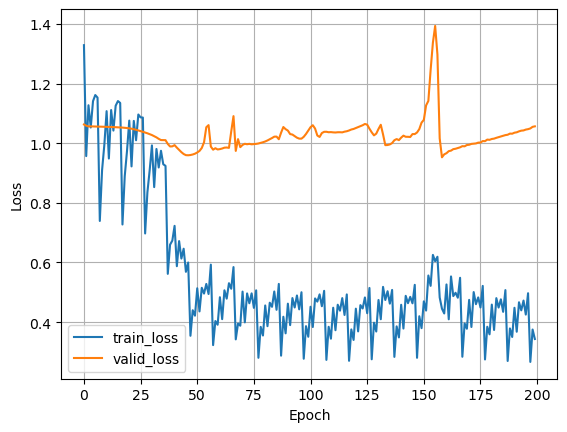

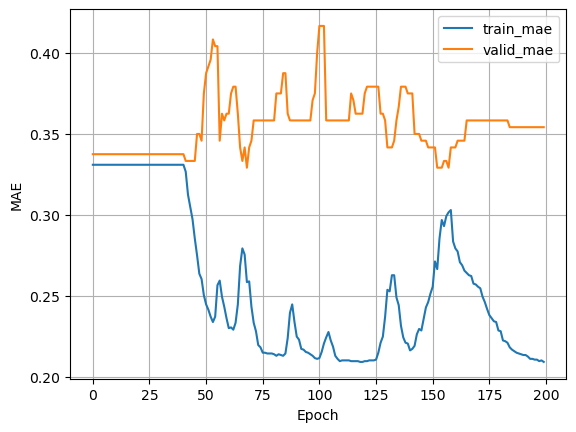

In [25]:
metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")

aggreg_metrics = []
agg_col = "epoch"
for i, dfg in metrics.groupby(agg_col):
    agg = dict(dfg.mean())
    agg[agg_col] = i
    aggreg_metrics.append(agg)

df_metrics = pd.DataFrame(aggreg_metrics)
df_metrics[["train_loss", "valid_loss"]].plot(
    grid=True, legend=True, xlabel='Epoch', ylabel='Loss')
df_metrics[["train_mae", "valid_mae"]].plot(
    grid=True, legend=True, xlabel='Epoch', ylabel='MAE')

In [26]:
from protein_utils.energy.potts import create_single_mutant

In [27]:
ret, energies = energy_calc_single_mutants(wt_np, h_i_a=synthetic_weights, e_i_a_j_b=np.zeros((L,q,L,q)))
mut_df = pd.DataFrame({"idx":ret.i, "mut_aa":ret.a, "energy":energies})
mut_df["pdb_idx"] = mut_df.idx + 1
#mut_df["energy_delta"] = mut_df.energy - wt_energy
mut_df["aa"] = mut_df.mut_aa.map(enc.int_to_alpha_dict)
mut_df["wt_aa"] = mut_df.idx.map(wt.__getitem__)

In [28]:
def get_bin_N_score(i, a):
    x = one_hot(torch.LongTensor(create_single_mutant(i, a, wt_np))).flatten()
    with torch.no_grad():
        logits = pytorch_model(x.float(), torch.LongTensor([0]))
        probas = torch.sigmoid(logits) # probability of each class L, P, H
        # find out what is the probability of N and return log of that
        #print(probas)
        return torch.log(1 - probas.squeeze()[0]).item()

In [29]:
bin_N_score = mut_df.apply(lambda x: get_bin_N_score(x['idx'], x['mut_aa']), axis=1)

In [30]:
from scipy.stats import spearmanr

In [31]:
spearmanr(bin_N_score, mut_df.energy)

SignificanceResult(statistic=0.4520987771587129, pvalue=7.831143792973136e-259)